#### Import Libraries

In [21]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec
import pickle

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [22]:
## options

BLyearstart = 1981
BLyearend = 2024
recalculateBL = True

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [23]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

In [24]:
from shapely.geometry import LineString
from shapely.ops import split


gdf = gpd.read_file('/Users/miguelsilveira/Documents/GitHub/marineheatwaves/200m/200m.shp')
b200 = gdf.to_crs(epsg= 4256)

# Build GeoDataFrame
b200_3 = b200

In [25]:
b200_3

,id,fid,id_pjuridi,Areas,geometry
0,10,sst_mean_nc_min_polys.15,14.0,2,"POLYGON ((-9.31939 38.47282, -9.35137 38.47248..."
1,1,sst_mean_nc_min_polys.1,4.0,1,"POLYGON ((-9.98243 39.10737, -9.98299 39.10987..."
2,6,sst_mean_nc_min_polys.6,17.0,3,"POLYGON ((-7.70448 36.9503, -7.77327 36.9315, ..."


In [26]:
def build_shape_mask(ds, shapefile):
    """
    Build a boolean mask on the native OISST grid.
    Assumes ds.lon is in 0-360 format.
    """

    gdf = shapefile.to_crs("EPSG:4326")

    # ---- convert shapefile lon from -180..180 → 0..360 ----
    gdf["geometry"] = gdf.geometry.translate(xoff=360)
    gdf["geometry"] = gdf.geometry.buffer(0)

    # grid spacing
    dlat = float(abs(ds.lat[1] - ds.lat[0]))
    dlon = float(abs(ds.lon[1] - ds.lon[0]))

    # raster transform (cell-centered grid)
    transform = from_origin(
        ds.lon.min().item() - dlon / 2,
        ds.lat.max().item() + dlat / 2,
        dlon,
        dlat
    )

    mask = geometry_mask(
        gdf.geometry,
        out_shape=(ds.dims["lat"], ds.dims["lon"]),
        transform=transform,
        invert=True
    )

    # flip latitude to match xarray ordering
    mask = mask[::-1, :]

    return xr.DataArray(
        mask,
        coords={"lat": ds.lat, "lon": ds.lon},
        dims=("lat", "lon")
    )


In [27]:

ref_ds = xr.open_dataset(r"/Volumes/Crucial X6/sst_merged.nc")
shape_masks = {'NW': build_shape_mask(ref_ds, b200_3. iloc[[0]]),
               'SW': build_shape_mask(ref_ds, b200_3.iloc[[1]]),
               'S': build_shape_mask(ref_ds, b200_3.iloc[[2]])}

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_57447/8589276.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_shape=(ds.dims["lat"], ds.dims["lon"]),
/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_57447/8589276.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_shape=(ds.dims["lat"], ds.dims["lon"]),
/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_57447/8589276.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a

## Get Baseline

In [29]:
if recalculateBL:
    baseline_df = pd.DataFrame()
    temp = xr.open_dataset(r"/Volumes/Crucial X6/sst_merged.nc", 
                        engine="netcdf4", decode_times=True)
    
    temp_sel = spatial_subset(temp)
    
    temp_sst = temp_sel["sst"]

    baseline_df = temp_sst.to_dataframe()

    baseline_df.reset_index(inplace= True)

    baseline_df.to_pickle(f'baseline.pkl')


In [30]:
baseline_df = pd.read_pickle('baseline.pkl')

## Years to Analyse

#### Slice datasets' coordinates

## Conversion to ordinal time

In [31]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [34]:
class Analyse:
    def __init__(self, shape_masks):
        self.oisst = xr.open_dataset(r'/Volumes/Crucial X6/sst_merged.nc',
                                    engine="netcdf4",
                                    decode_times=True)
        
        self.shape_masks = shape_masks
        
        self.sliced = {}
        for zone in ['NW', 'SW', 'S']:
            self.sliced[zone] = self.slice(zone)

        self.results = {}
        for zone in ['NW', 'SW', 'S']:
            self.results[zone] = self.detect_MHW(zone)
        
        self.table = self.create_table()
        self.table.to_excel('mhwSummary200m.xlsx')


    def slice(self, zone):
        print('Slicing OISST Data')
    
        oisst_sel = spatial_subset(self.oisst).where(self.shape_masks[zone])
        oisst_sst = oisst_sel["sst"]
        df = oisst_sst.to_dataframe().reset_index()
        df = df.dropna(subset=['sst'])
        df["year"] = pd.to_datetime(df["time"]).dt.year

        return df
    
    def detect_MHW(self, zone, climatology_period=(BLyearstart, BLyearend)):
        print('Detecting MHWs')

        results = []

        grouped = self.sliced[zone].groupby(["lat", "lon"])
        baseline_groups = baseline_df.groupby(["lat", "lon"])

        for (lat, lon), group in grouped:
            print(lat, lon)
            # --- main time series ---
            sst = group["sst"].values
            time = group["time"].values
            time_ord = to_ordinal(time)

            # --- baseline ---
            try:
                base_group = baseline_groups.get_group((lat, lon))
            except KeyError:
                continue

            base_sst = base_group["sst"].values
            base_time = base_group["time"].values
            base_time_ord = to_ordinal(base_time)

            sst = sst.copy()

            # --- detect MHW ---
            mhw_ev, clim = mhw.detect(
                time_ord,
                sst,
                climatologyPeriod=list(climatology_period),
                alternateClimatology=[base_time_ord, base_sst]
            )

            if mhw_ev["n_events"] == 0:
                continue

            for i in range(mhw_ev["n_events"]):
                results.append({
                    "year": mhw_ev["date_start"][i].year,
                    "lat": lat,
                    "lon": lon,
                    "duration": mhw_ev["duration"][i],
                    "max_intensity": mhw_ev["intensity_max"][i],
                    "mean_intensity": mhw_ev["intensity_mean"][i],
                    "cumulative_intensity": mhw_ev["intensity_cumulative"][i],
                })
        return pd.DataFrame(results)
    

    def create_table(self):
        print('Creating Table')
        nw = self.results['NW'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
        nw[('n_events', 'mean')] = self.results['NW'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
        nw[('n_events', 'total')] = self.results['NW'].groupby('year').size()

        sw = self.results['SW'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
        sw[('n_events', 'mean')] = self.results['SW'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
        sw[('n_events', 'total')] = self.results['SW'].groupby('year').size()

        s = self.results['S'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
        s[('n_events', 'mean')] = self.results['S'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
        s[('n_events', 'total')] = self.results['S'].groupby('year').size()

        final_df = pd.concat([nw, sw, s], keys=['NW', 'SW', 'S']).T
        return final_df

In [35]:
a = Analyse(shape_masks)

Slicing OISST Data
Slicing OISST Data
Slicing OISST Data
Detecting MHWs
37.125 350.875
37.125 351.125
37.375 351.125
37.625 351.125
37.875 351.125
38.125 351.125
38.375 350.875
38.375 351.125
38.625 350.375
38.625 350.625
38.875 350.125
38.875 350.375
Detecting MHWs
39.125 350.125
39.125 350.375
39.125 350.625
39.375 350.375
39.375 350.625
39.625 350.625
39.625 350.875
39.875 350.625
39.875 350.875
40.125 350.625
40.125 350.875
40.125 351.125
40.375 350.625
40.375 350.875
40.375 351.125
40.625 350.875
40.625 351.125
40.875 350.875
40.875 351.125
41.125 350.875
41.125 351.125
41.375 350.875
41.375 351.125
41.625 350.875
41.625 351.125
Detecting MHWs
36.875 351.125
36.875 351.375
36.875 351.625
36.875 351.875
37.125 351.375
37.125 352.375
Creating Table


In [36]:
import pickle

with open("mhw_200m_zones.pkl", "wb") as f:
    pickle.dump(a, f)

In [37]:
with open("mhw_200m_zones.pkl", "rb") as f:
    a = pickle.load(f)

In [38]:
nw = a.results['NW'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
nw[('n_events', 'mean')] = a.results['NW'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
nw[('n_events', 'total')] = a.results['NW'].groupby('year').size()

sw = a.results['SW'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
sw[('n_events', 'mean')] = a.results['SW'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
sw[('n_events', 'total')] = a.results['SW'].groupby('year').size()

s = a.results['S'].drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
s[('n_events', 'mean')] = a.results['S'].groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
s[('n_events', 'total')] = a.results['S'].groupby('year').size()

a.table = pd.concat([nw, sw, s], keys=['NW', 'SW', 'S'])

In [39]:
import plotly.express as px
import plotly.graph_objects as go

In [40]:
meanNEventsNW = a.table.loc['NW']
meanNEventsSW = a.table.loc['SW']
meanNEventsS = a.table.loc['S']

dfNW = pd.DataFrame(
    meanNEventsNW.reset_index()
)

dfSW = pd.DataFrame(
    meanNEventsSW.reset_index()
)
dfS = pd.DataFrame(
    meanNEventsS.reset_index()
)

fig = go.Figure()



In [41]:
import seaborn as sns

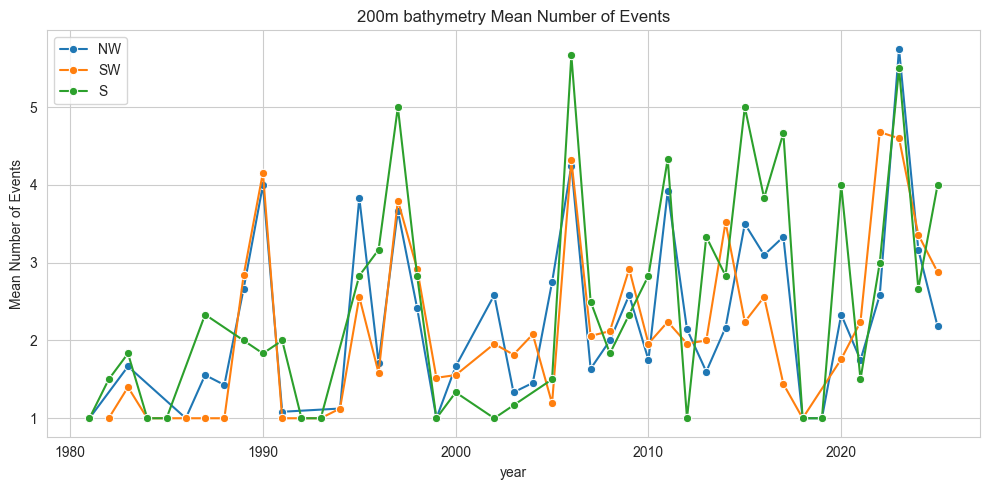

In [63]:
sns.set_style("whitegrid")
fig, (ax) = plt.subplots(figsize=(10, 5))

sns.lineplot(dfNW, y= ('n_events', 'mean'), x= 'year', ax= ax, marker= 'o', label="NW")
sns.lineplot(dfSW, y= ('n_events', 'mean'), x= 'year', ax= ax, marker= 'o', label="SW")
sns.lineplot(dfS, y= ('n_events', 'mean'), x= 'year', ax= ax, marker= 'o', label="S")

ax.set_ylabel('Mean Number of Events')


ax.set_title('200m bathymetry Mean Number of Events')


plt.tight_layout()

plt.show()

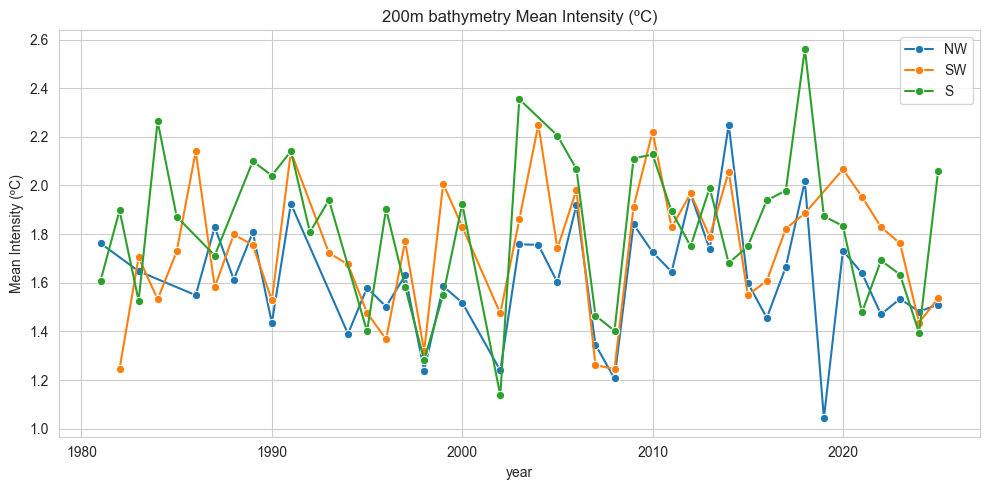

In [61]:
sns.set_style("whitegrid")
fig, (ax) = plt.subplots (figsize=(10, 5))

sns.lineplot(dfNW, y= ('mean_intensity', 'mean'), x= 'year', ax= ax, marker= 'o', label="NW")
sns.lineplot(dfSW, y= ('mean_intensity', 'mean'), x= 'year', ax= ax, marker= 'o', label="SW")
sns.lineplot(dfS, y= ('mean_intensity', 'mean'), x= 'year', ax= ax,  marker= 'o', label="S")

ax.set_ylabel('Mean Intensity (ºC)')


ax.set_title('200m bathymetry Mean Intensity (ºC)')


plt.tight_layout()

plt.show()

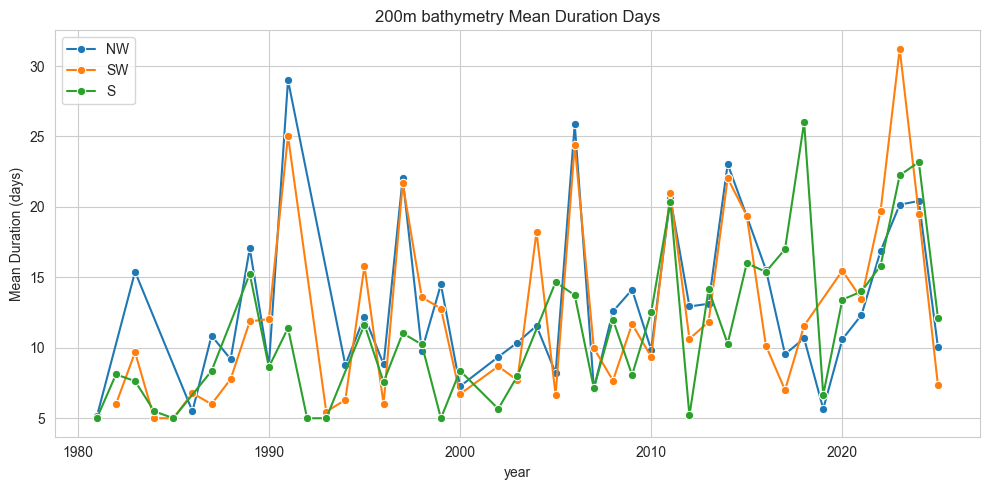

In [62]:
sns.set_style("whitegrid")
fig, (ax) = plt.subplots (figsize=(10, 5))

sns.lineplot(dfNW, y= ('duration', 'mean'), x= 'year', ax= ax, marker= 'o', label="NW")
sns.lineplot(dfSW, y= ('duration', 'mean'), x= 'year', ax= ax, marker= 'o', label="SW")
sns.lineplot(dfS, y= ('duration', 'mean'), x= 'year', ax= ax, marker= 'o', label="S")

ax.set_ylabel('Mean Duration (days)')


ax.set_title('200m bathymetry Mean Duration Days')

plt.tight_layout()

plt.show()

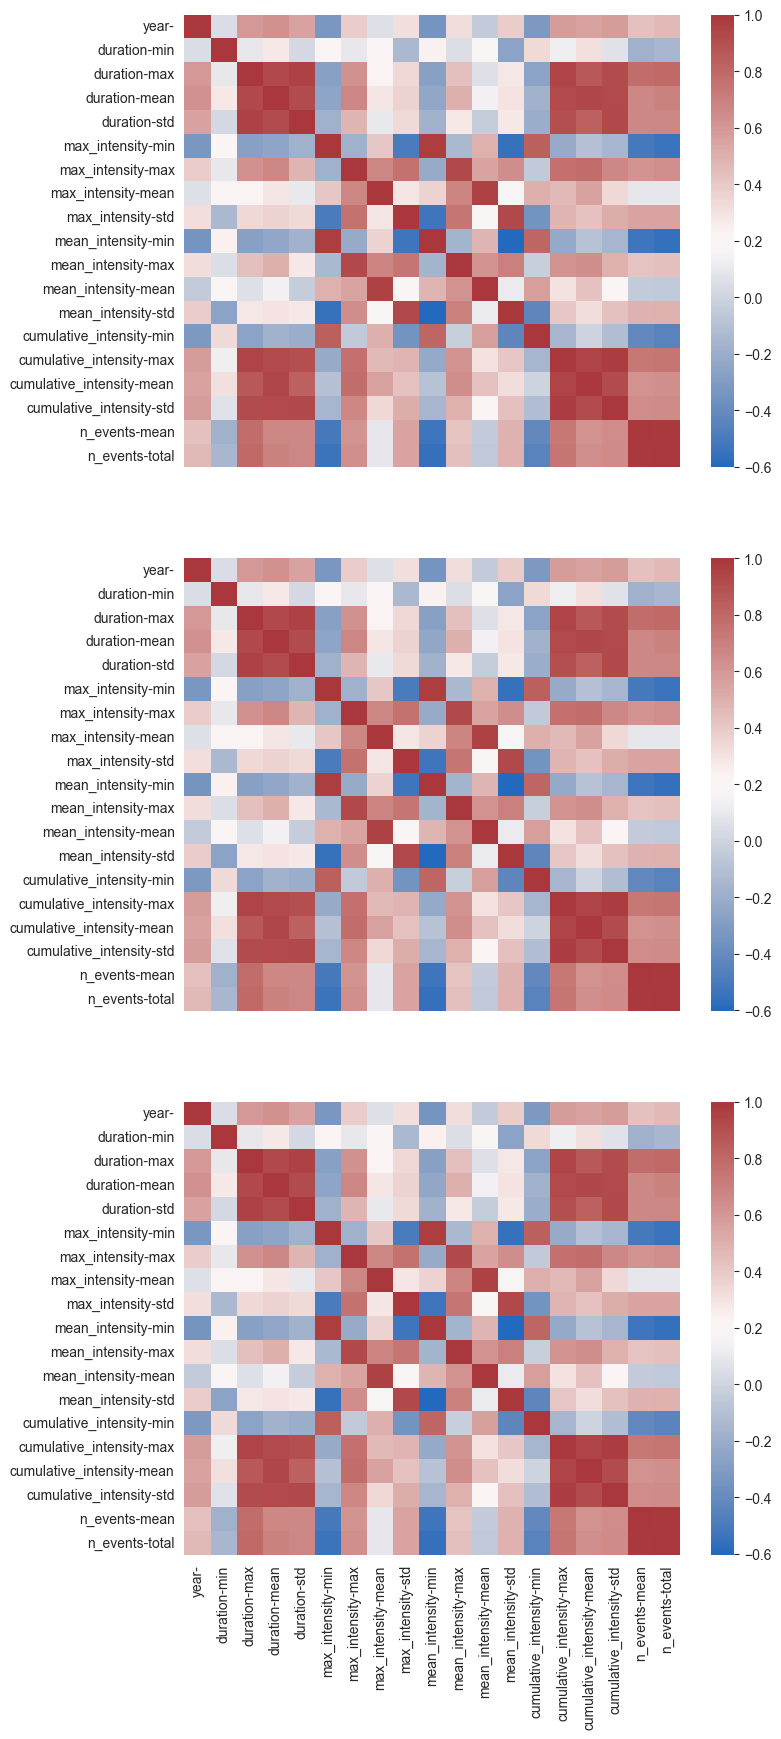

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8, 20), sharex= True)

sns.heatmap(dfS.corr('spearman'), cmap= 'vlag', ax= ax1)
sns.heatmap(dfS.corr('spearman'), cmap= 'vlag', ax= ax2)
sns.heatmap(dfS.corr('spearman'), cmap= 'vlag', ax= ax3)

ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('')

ax1.set_ylabel('')
ax2.set_ylabel('')
ax3.set_ylabel('')

plt.show()